### **Estudo de Reconstrução 3D.**

Este notebook tem por objetivo estudar e registrar ferramentas e fórmulas teóricas para cálculo da profundidade estimada de cada pixel para reconstrução 3d.

**Equação de Gauss para Lentes:**

>$\frac{1}{f} = \frac{1}{d_o} + \frac{1}{d_i}$ 

Hipoteticamente, no experimento final conheceremos a distância focal *$f$* e a distância do centro óptico ao sensor *$d_i$*. Ou seja, facilmente obtemos a distância da câmera ao objeto *$d_o$*.

---

Adicionalmente, como definimos a distância do sensor fixa **$d_i = d_s$**, então para uma determinada imagem da pilha **$I_k$**, os pontos com maior nitidez correspondem aos pontos próximos a distância **$d_o$**, com o círculo de confusão **$c \rightarrow 0$**

$\Rightarrow d_o = \frac{f \cdot d_s}{d_s - f}$ 

Portanto, vamos usar a seleção dos pixels com base na nitidez, utilizando o **Laplaciano**. 

In [1]:
# Bibliotecas.
from utils.align_images import load_images
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
from IPython.display import Image

In [2]:
# Imagens Alinhadas.
images = load_images("./images/aligned")


Fase 1.1: Ordenação.
Ordem de carregamento detectada: ['aligned_0000.jpg', 'aligned_0001.jpg', 'aligned_0002.jpg'] ...


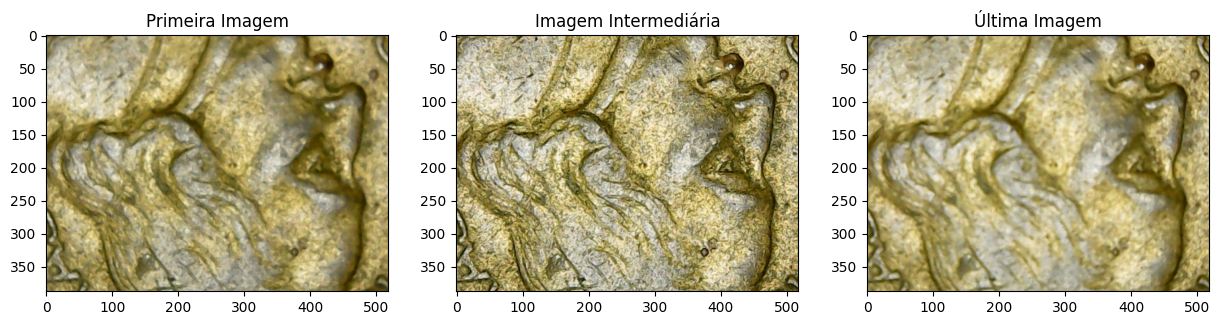

In [39]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(cv.cvtColor(images[0], cv.COLOR_BGR2RGB), cmap='jet')
ax2.imshow(cv.cvtColor(images[20], cv.COLOR_BGR2RGB), cmap='jet')
ax3.imshow(cv.cvtColor(images[-1], cv.COLOR_BGR2RGB), cmap='jet')

ax1.set_title("Primeira Imagem")
ax2.set_title("Imagem Intermediária")
ax3.set_title("Última Imagem")

plt.show()

A fim de avaliar a abordagem de Laplaciano, abaixo seguem os teste da metodologia  utilizando as imagens de referência $i_{0}$ e em foco $i_{20}$. Como nas camadas de foco, a frequência de nitidez gerada pelo Laplaciano é alta, observamos os resultados de duas maneiras: **com e sem filtro passa-baixa.**

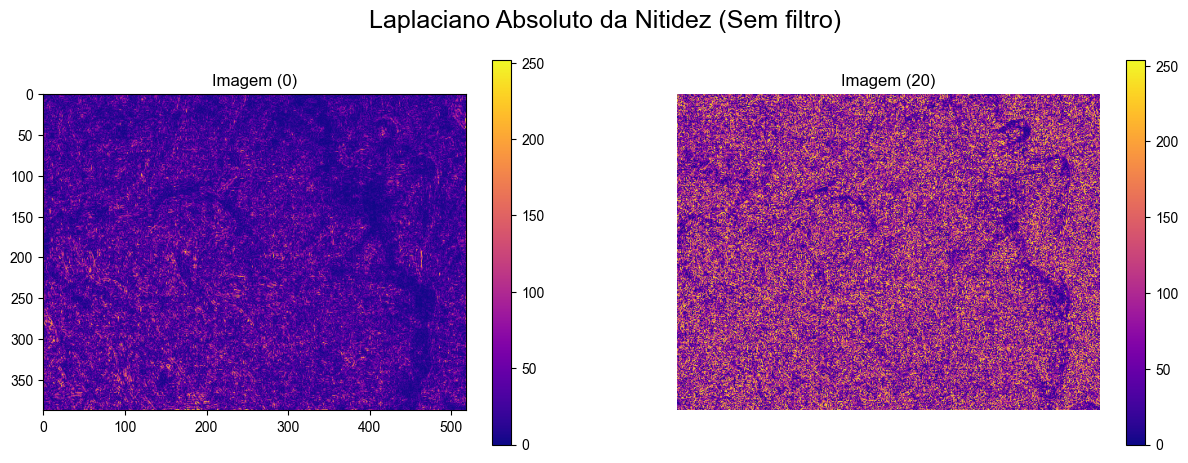

In [61]:
# Teste de Laplaciano Absoluto (Sem filtro).
# [[ 2.,  0.,  2.],
#  [ 0., -8.,  0.], 
#  [ 2.,  0.,  2.]] Kernel=3

# Imagem de Referência.
gray_ref = cv.cvtColor(images[0], cv.COLOR_BGR2GRAY)
lap_ref = cv.Laplacian(gray_ref, cv.CV_64F, ksize=3)
abs_lap_ref = np.absolute(lap_ref)
edge_ref = np.uint8(abs_lap_ref)

# Imagem em Foco.
gray_focus = cv.cvtColor(images[20], cv.COLOR_BGR2GRAY)
lap_focus = cv.Laplacian(gray_focus, cv.CV_64F, ksize=3)
abs_lap_focus = np.absolute(lap_focus)
edge_focus = np.uint8(abs_lap_focus)

# Gráfico.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plt.rcParams['font.family'] = 'Arial'
im1 = ax1.imshow(edge_ref, cmap="plasma")
im2 = ax2.imshow(edge_focus, cmap="plasma")
ax1.set_title("Imagem (0)")
ax2.set_title("Imagem (20)")
fig.colorbar(im1, ax=ax1)
fig.colorbar(im2, ax=ax2)
fig.suptitle("Laplaciano Absoluto da Nitidez (Sem filtro)", fontsize=18, fontweight=500)
plt.axis("off")
plt.show()

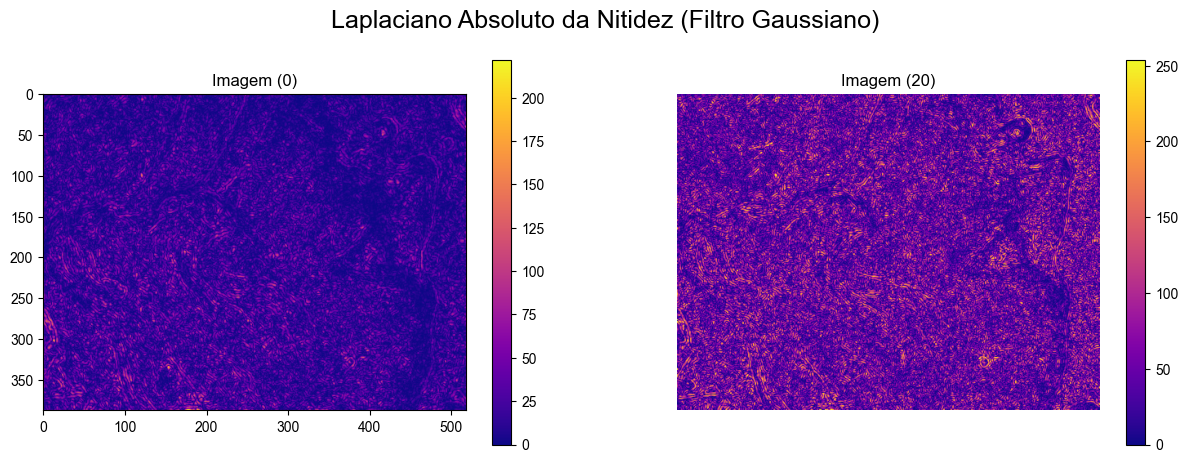

In [62]:
# Teste de Laplaciano Absoluto (Com filtro Gaussiano).
# [[ 2.,  0.,  2.],
#  [ 0., -8.,  0.], 
#  [ 2.,  0.,  2.]] Kernel=3

# Imagem de Referência.
gray_ref = cv.cvtColor(images[0], cv.COLOR_BGR2GRAY)
lap_ref = cv.Laplacian(gray_ref, cv.CV_64F, ksize=3)
gauss_ref = cv.GaussianBlur(lap_ref, (3, 3), 0)
abs_lap_ref = np.absolute(gauss_ref)
edge_ref = np.uint8(abs_lap_ref)

# Imagem em Foco.
gray_focus = cv.cvtColor(images[20], cv.COLOR_BGR2GRAY)
lap_focus = cv.Laplacian(gray_focus, cv.CV_64F, ksize=3)
gauss_focus = cv.GaussianBlur(lap_focus, (3, 3), 0)
abs_lap_focus = np.absolute(gauss_focus)
edge_focus = np.uint8(abs_lap_focus)

# Gráfico.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plt.rcParams['font.family'] = 'Arial'
im1 = ax1.imshow(edge_ref, cmap="plasma")
im2 = ax2.imshow(edge_focus, cmap="plasma")
ax1.set_title("Imagem (0)")
ax2.set_title("Imagem (20)")
fig.colorbar(im1, ax=ax1)
fig.colorbar(im2, ax=ax2)
fig.suptitle("Laplaciano Absoluto da Nitidez (Filtro Gaussiano)", fontsize=18, fontweight=500)
plt.axis("off")
plt.show()

In [ ]:
# Criar caixa de foco, com base no Módulo do Laplaciano (depois testar com outras métricas).
h, w = images[1].shape[:2]
n = len(images)

sharpness_cube = np.zeros((h, w, n), dtype=np.float32) # Cubo de Foco.

for i, img in enumerate(images):
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    lap = cv.Laplacian(gray, cv.CV_64F, ksize=1)
    abs_lap = np.absolute(lap)
    edge = np.uint8(abs_lap)

# Trabalhando...    